# Pattern #3: Planning (ReAct) — Think, Act, Observe

**LangGraph Implementation**

## Overview

The ReAct (Reasoning + Acting) pattern maps perfectly to a LangGraph cycle:

```
START → think → ┬─ "retrieve" → retrieve ─┐
          ↑      ├─ "search"   → search   ─┤
          │      └─ "answer"   → answer → END
          │                                │
          └────────────────────────────────┘
```

The agent:
1. **Thinks**: Plans next action based on query and observations
2. **Acts**: Executes action (RAG retrieval OR web search)
3. **Observes**: Processes action results (loops back to think)
4. **Answers**: Provides final synthesized response

LangGraph makes the loop explicit: `think` has conditional edges to action nodes, and action nodes edge back to `think`.

**Combines Internal RAG + External web_search**

In [17]:
import sys
import re
from pathlib import Path
sys.path.append('..')

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from IPython.display import Image, display
import operator

from utils import create_llm_provider, get_config
from rag_internal import MedicalKnowledgeRetriever
from tools import get_web_search_tool


def show_graph(runnable):
    """Render the LangGraph graph as a Mermaid diagram."""
    try:
        display(Image(runnable.get_graph().draw_mermaid_png()))
    except Exception:
        print(runnable.get_graph().draw_mermaid())

_project_root = Path.cwd() if (Path.cwd() / "data" / "medical_guides").exists() else Path.cwd().parent
DOCS_DIR = _project_root / "data" / "medical_guides"

config = get_config()
llm = create_llm_provider()
retriever = MedicalKnowledgeRetriever(docs_directory=str(DOCS_DIR))
web_search = get_web_search_tool()

if not retriever._is_indexed:
    print("Indexing documents...")
    stats = retriever.index_documents()
    status = stats.get("status", "unknown")
    if status == "indexed":
        print(f"Indexed {stats.get('chunk_count', 0)} chunks from {stats.get('document_count', 0)} documents")
    elif status in ("no_documents", "no_content"):
        print(f"No documents found in {DOCS_DIR}. Add .txt files for RAG.")
    else:
        print(f"Status: {status}")
else:
    print(f"Documents already indexed: {retriever.get_stats()['total_chunks']} chunks")

print(f"\nUsing model: {config.get('model')}")
print("Available actions: RETRIEVE (internal RAG), SEARCH (web), ANSWER (finish)")

Documents already indexed: 27 chunks

Using model: openai/gpt-4o-mini
Available actions: RETRIEVE (internal RAG), SEARCH (web), ANSWER (finish)


## Project Structure

All notebooks in this repo share a set of utility modules in the parent directory:

| Module | Purpose |
|---|---|
| `utils/` | LLM provider factory (`create_llm_provider`), config loader (`get_config`), token counter |
| `rag_internal/` | Internal RAG retriever backed by Qdrant — represents *agent memory*, not a tool |
| `tools/` | External tools: `web_search` (Tavily) and `booking_tool` (local JSON lookup) |
| `config/` | `models.yaml` and `params.yaml` — provider, model, and RAG settings |
| `data/` | Medical knowledge `.txt` files for RAG and `bookings.json` for the booking tool |

This notebook uses `utils/`, `rag_internal/` (internal RETRIEVE action), and `tools/web_search` (external SEARCH action) — the ReAct pattern combines both.

### Validation

In [18]:
assert config.get("model"), "config.get('model') should be set"
assert retriever._is_indexed, "Retriever should be indexed"
assert callable(web_search.search), "web_search tool ready"
print("\u2713 Setup valid: config, LLM, retriever, and web_search ready.")

✓ Setup valid: config, LLM, retriever, and web_search ready.


## Step 1: Define the State

The ReAct state tracks the evolving reasoning process.

We use `Annotated[list, operator.add]` for `observations` and `sources` — this tells LangGraph to **append** new items instead of replacing the list.

```python
observations: Annotated[list, operator.add]  # each node appends, never overwrites
```

In [19]:
class ReActState(TypedDict):
    query: str
    observations: Annotated[list, operator.add]
    sources: Annotated[list, operator.add]
    current_thought: str
    current_action: str
    current_action_query: str
    final_answer: str
    iteration: int
    max_iterations: int
    total_tokens: int

## Step 2: Define the Nodes

| Node | Purpose | Output |
|---|---|---|
| `think` | Plan next action based on observations so far | Sets `current_action` (RETRIEVE / SEARCH / ANSWER) |
| `retrieve` | Pull from internal RAG | Appends to `observations` |
| `search` | Query the web via Tavily | Appends to `observations` |
| `answer` | Synthesize final response from all observations | Sets `final_answer` |

In [20]:
def _safe(text: str) -> str:
    """Sanitise dynamic text before printing to Jupyter stdout.

    Replaces any surrogate or unrepresentable Unicode code points with the
    standard replacement character (U+FFFD) so Jupyter's kernel serialiser
    never encounters invalid UTF-8 sequences.
    """
    return text.encode("utf-8", errors="replace").decode("utf-8")


def think_node(state: ReActState) -> dict:
    """Plan the next action based on query and observations."""
    iteration = state["iteration"] + 1

    print(f"\n{'-' * 70}")
    print(f"THINK (iteration {iteration})")
    print(f"{'-' * 70}")

    if iteration > state["max_iterations"]:
        print("Max iterations reached - forcing ANSWER.")
        return {
            "current_action": "ANSWER",
            "current_thought": "Max iterations reached, answering now.",
            "iteration": iteration,
        }

    obs_text = "\n".join([f"- {o}" for o in state["observations"]]) if state["observations"] else "None yet"

    response = llm.generate(
        prompt=(
            f"User Question: {state['query']}\n\n"
            f"Previous Observations:\n{obs_text}\n\n"
            f"What should you do next?"
        ),
        system_prompt=(
            "You are a healthcare assistant agent using ReAct (Reasoning + Acting).\n"
            "Plan your next action: RETRIEVE (internal knowledge) or SEARCH (web) or ANSWER (finish).\n\n"
            "Use RETRIEVE for: medical procedures, clinical guidelines, policy information\n"
            "Use SEARCH for: hospital hours, contacts, current announcements\n"
            "Use ANSWER when: you have enough information to respond\n\n"
            "Format:\nTHOUGHT: <your reasoning>\nACTION: <RETRIEVE|SEARCH|ANSWER>\nQUERY: <search query if RETRIEVE or SEARCH>"
        ),
    )
    text = response["response"]

    thought_match = re.search(r"THOUGHT:(.+?)(?=ACTION:|$)", text, re.DOTALL | re.IGNORECASE)
    action_match = re.search(r"ACTION:\s*(\w+)", text, re.IGNORECASE)
    query_match = re.search(r"QUERY:(.+)", text, re.IGNORECASE)

    thought = thought_match.group(1).strip() if thought_match else "Continue processing"
    action = action_match.group(1).strip().upper() if action_match else "ANSWER"
    action_query = query_match.group(1).strip() if query_match else state["query"]

    if action not in ("RETRIEVE", "SEARCH", "ANSWER"):
        action = "ANSWER"

    print(f"\n>> THOUGHT: {_safe(thought)}")
    print(f">> ACTION:  {action}")
    if action != "ANSWER":
        print(f">> QUERY:   {_safe(action_query)}")

    return {
        "current_thought": thought,
        "current_action": action,
        "current_action_query": action_query,
        "iteration": iteration,
        "total_tokens": state["total_tokens"] + response["total_tokens"],
    }


def retrieve_node(state: ReActState) -> dict:
    """Retrieve from internal RAG."""
    print(f"\n[RETRIEVE] {_safe(state['current_action_query'])}")

    chunks = retriever.retrieve(state["current_action_query"], max_k=3)
    if chunks:
        # Build full observation — no truncation so answer_node has complete context
        parts = [
            f"[{c['source']}, Page {c.get('page', '?')}] {c['text']}"
            for c in chunks
        ]
        observation = f"Internal knowledge ({len(chunks)} sources):\n" + "\n".join(parts)
        new_sources = [c["source"] for c in chunks]
    else:
        observation = "No relevant internal knowledge found."
        new_sources = []

    # Truncate only for display — state stores the full text
    print(f"\n[OBSERVATION] {_safe(observation[:300])}...")

    return {
        "observations": [observation],
        "sources": new_sources,
    }


def search_node(state: ReActState) -> dict:
    """Search the web via Tavily."""
    print(f"\n[SEARCH] {_safe(state['current_action_query'])}")

    search_result = web_search.search(state["current_action_query"], max_results=3)
    # Store full formatted results — no truncation so answer_node has complete context
    formatted = web_search.format_results(search_result)
    urls = [r["url"] for r in search_result.get("results", [])]

    observation = f"Web search results:\n{formatted}"

    # Truncate only for display
    print(f"\n[OBSERVATION] {_safe(observation[:300])}...")

    return {
        "observations": [observation],
        "sources": urls,
    }


def answer_node(state: ReActState) -> dict:
    """Generate final answer from all observations."""
    print(f"\n{'=' * 70}")
    print("GENERATING FINAL ANSWER")
    print(f"{'=' * 70}")

    obs_text = "\n\n".join([f"Observation {i+1}:\n{obs}" for i, obs in enumerate(state["observations"])])

    response = llm.generate(
        prompt=(
            f"User Question: {state['query']}\n\n"
            f"Information Gathered:\n{obs_text}\n\n"
            f"Provide a comprehensive final answer."
        ),
        system_prompt=(
            "You are a healthcare assistant providing a final answer. "
            "Synthesize the observations into a clear, helpful response. "
            "Cite sources when referencing specific information. "
            'Always end with: "This is educational information; verify with the hospital / consult your clinician."'
        ),
    )

    print(f"\n[ANSWER]\n{_safe(response['response'])}")

    return {
        "final_answer": response["response"],
        "total_tokens": state["total_tokens"] + response["total_tokens"],
    }

## Step 3: Build the Graph

The `think` node has **conditional edges** that route to the chosen action.
Action nodes (`retrieve`, `search`) edge back to `think`, creating the ReAct loop.
The `answer` node edges to `END`.

```
START → think → ┬─ "RETRIEVE" → retrieve ─┐
          ↑      ├─ "SEARCH"   → search   ─┤
          │      └─ "ANSWER"   → answer → END
          └─────────────────────────────────┘
```

ReAct graph compiled ✓


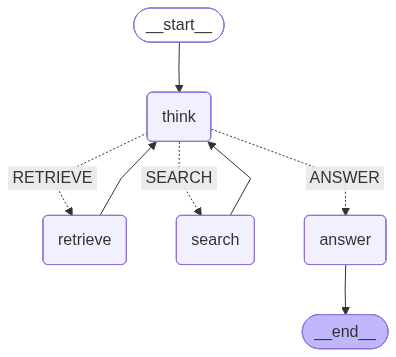

In [21]:
def route_action(state: ReActState) -> str:
    """Route to the action chosen by the think node."""
    return state["current_action"]


graph = StateGraph(ReActState)

graph.add_node("think", think_node)
graph.add_node("retrieve", retrieve_node)
graph.add_node("search", search_node)
graph.add_node("answer", answer_node)

graph.add_edge(START, "think")
graph.add_conditional_edges("think", route_action, {
    "RETRIEVE": "retrieve",
    "SEARCH": "search",
    "ANSWER": "answer",
})
graph.add_edge("retrieve", "think")
graph.add_edge("search", "think")
graph.add_edge("answer", END)

react_app = graph.compile()
print("ReAct graph compiled \u2713")

show_graph(react_app)

## Helper: Run the Agent

In [22]:
def run_react(query: str, max_iterations: int = 5) -> dict:
    """Run the ReAct agent and print summary."""
    import time

    print("=" * 70)
    print("REACT AGENT STARTING")
    print("=" * 70)
    print(f"Query: {query}\n")

    start = time.time()
    result = react_app.invoke({
        "query": query,
        "observations": [],
        "sources": [],
        "current_thought": "",
        "current_action": "",
        "current_action_query": "",
        "final_answer": "",
        "iteration": 0,
        "max_iterations": max_iterations,
        "total_tokens": 0,
    })
    elapsed = int((time.time() - start) * 1000)

    print(f"\n{'=' * 70}")
    print("SUMMARY")
    print(f"{'=' * 70}")
    print(f"Iterations: {result['iteration']}")
    print(f"Total tokens: {result['total_tokens']}")
    print(f"Total time: {elapsed}ms")
    print(f"Sources: {len(set(result['sources']))}")

    return result

## Example 1: Policy + Operational Query

This query needs **both** internal RAG (eczema protocol) and web search (clinic hours).
Watch the agent decide which action to take at each step.

In [23]:
result1 = run_react(
    "What is the skin care protocol for eczema and when is the dermatology clinic open today?"
)

REACT AGENT STARTING
Query: What is the skin care protocol for eczema and when is the dermatology clinic open today?


----------------------------------------------------------------------
THINK (iteration 1)
----------------------------------------------------------------------

>> THOUGHT: I need to provide information on the skin care protocol for eczema, which falls under medical procedures and clinical guidelines. Additionally, I need to find out the current hours for the dermatology clinic today, which requires a web search. Therefore, I will first retrieve the eczema skin care protocol and then search for the clinic hours.
>> ACTION:  RETRIEVE
>> QUERY:   skin care protocol for eczema

[RETRIEVE] skin care protocol for eczema

[OBSERVATION] Internal knowledge (3 sources):
[common_conditions, Page ?] ongue
- Rapid pulse
- Dizziness or fainting
- Severe skin rash
Call emergency services immediately!

=== SKIN RASH ===

Common Causes:
- Contact dermatitis (reaction to substance)
-

## Example 2: Medical Guidelines Only

A purely internal query — the agent should RETRIEVE from RAG without needing web search.

In [24]:
result2 = run_react("What precautions should I take before blood tests?")

REACT AGENT STARTING
Query: What precautions should I take before blood tests?


----------------------------------------------------------------------
THINK (iteration 1)
----------------------------------------------------------------------

>> THOUGHT: The user is asking for precautions to take before blood tests, which falls under medical procedures and clinical guidelines. I can retrieve information on this topic from my internal knowledge base.
>> ACTION:  RETRIEVE
>> QUERY:   precautions before blood tests

[RETRIEVE] precautions before blood tests

[OBSERVATION] Internal knowledge (3 sources):
[appointment_preparation, Page ?] s, foods, environmental)
   - Current medications and supplements
   - Recent lifestyle changes

3. Questions to Prepare:
   - Write down questions beforehand
   - Prioritize most important concerns
   - Ask about diagnosis, treatment...

----------------------------------------------------------------------
THINK (iteration 2)
---------------------------

## Pattern Summary

### LangGraph vs From-Scratch

| Aspect | From-Scratch | LangGraph |
|---|---|---|
| Loop control | `for` loop + regex parsing | Conditional edges + cycle in graph |
| Action routing | `if/elif` in `act()` method | `add_conditional_edges("think", ...)` |
| State accumulation | Manual list append | `Annotated[list, operator.add]` reducer |
| Max iterations | `range(max_iterations)` | Check in `think_node`, force ANSWER |

### Key LangGraph Features Used

- **Annotated reducers** — `Annotated[list, operator.add]` appends to lists across iterations
- **Conditional edges** — `think` routes to `retrieve`, `search`, or `answer`
- **Cycles** — action nodes edge back to `think`, forming the ReAct loop
- **Typed state** — `ReActState` enforces what data exists at each step

### Graph Structure

```
START → think → ┬─ retrieve ─┐
          ↑      ├─ search   ─┤
          │      └─ answer → END
          └──────────────────┘
```

ReAct is one of the most powerful single-agent patterns, and LangGraph makes its cyclic nature explicit and manageable.